## Nama : Dzhahira Shafa
## NIM : 09011382227150
# **Pengolahan Citra**

### 1. Pengumpulan & Persiapan Dataset

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Layer, Flatten
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Pra-pemrosesan Citra

In [ ]:
batch_size = 32
img_size = 224

datagen = ImageDataGenerator(rescale=1/255.,
                             zoom_range=0.8,
                             validation_split=0.15)

train_generator = datagen.flow_from_directory('/content/drive/MyDrive/UAS Citra/train',
                                                target_size=(img_size, img_size),
                                                batch_size=batch_size,
                                                shuffle=True,
                                                class_mode='categorical',
                                                subset='training')

validation_generator = datagen.flow_from_directory('/content/drive/MyDrive/UAS Citra/test',
                                                    target_size=(img_size, img_size),
                                                    batch_size=batch_size,
                                                    shuffle=False,
                                                    class_mode='categorical',
                                                    subset='validation')

Found 251 images belonging to 2 classes.
Found 14 images belonging to 2 classes.


### 3. Pembuatan Model CNN
menggunakan arsitektur VGG16 dengan lapisan kovolusi, pooling, activation ReLU, GlobalAveragePooling2D, dense, dan output softmax

In [ ]:
base_model = VGG16(include_top = False,
                   weights = 'imagenet',
                   input_shape = (img_size,img_size,3))

last = base_model.layers[-2].output
x = GlobalAveragePooling2D()(last)
x = Dense(512,'relu')(x)
x = Dense(2, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=x)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 4. Kompilasi Model
Model dikompilasi menggunakan optimizer `Adam`, loss function `categorical_crossentropy`,
dan metrik `accuracy`.

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.0001),
              metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,978,370 (57.14 MB)

 Trainable params: 14,978,370 (57.14 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Pelatihan Model

In [ ]:
model_name = "model.keras"  # Change the extension to .keras
checkpoint = ModelCheckpoint(model_name,
                            monitor="val_loss",
                            mode="min",
                            save_best_only = True,
                            verbose=1)

earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0, patience = 5, verbose = 1, restore_best_weights=True)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss',
                                            patience=3,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=0.00000001)

In [ ]:
history = model.fit(train_generator,
                    epochs=10,
                    validation_data=validation_generator,
                    callbacks=[checkpoint,earlystopping,learning_rate_reduction])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6412 - loss: 0.6722
Epoch 1: val_loss improved from inf to 0.45572, saving model to model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 99s 7s/step - accuracy: 0.6461 - loss: 0.6684 - val_accuracy: 0.7857 - val_loss: 0.4557 - learning_rate: 1.0000e-04
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.7278 - loss: 0.5752
Epoch 2: val_loss improved from 0.45572 to 0.32022, saving model to model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 57s 737ms/step - accuracy: 0.7292 - loss: 0.5716 - val_accuracy: 0.9286 - val_loss: 0.3202 - learning_rate: 1.0000e-04
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.7934 - loss: 0.4490
Epoch 3: val_loss did not improve from 0.32022
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 783ms/step - accuracy: 0.7907 - loss: 0.4542 - val_accuracy: 0.9286 - val_loss: 0.3609 - learning_rate: 1.0000e-04
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.8586 - loss: 0.4023
Epoch 4: val_loss improved from 0.32

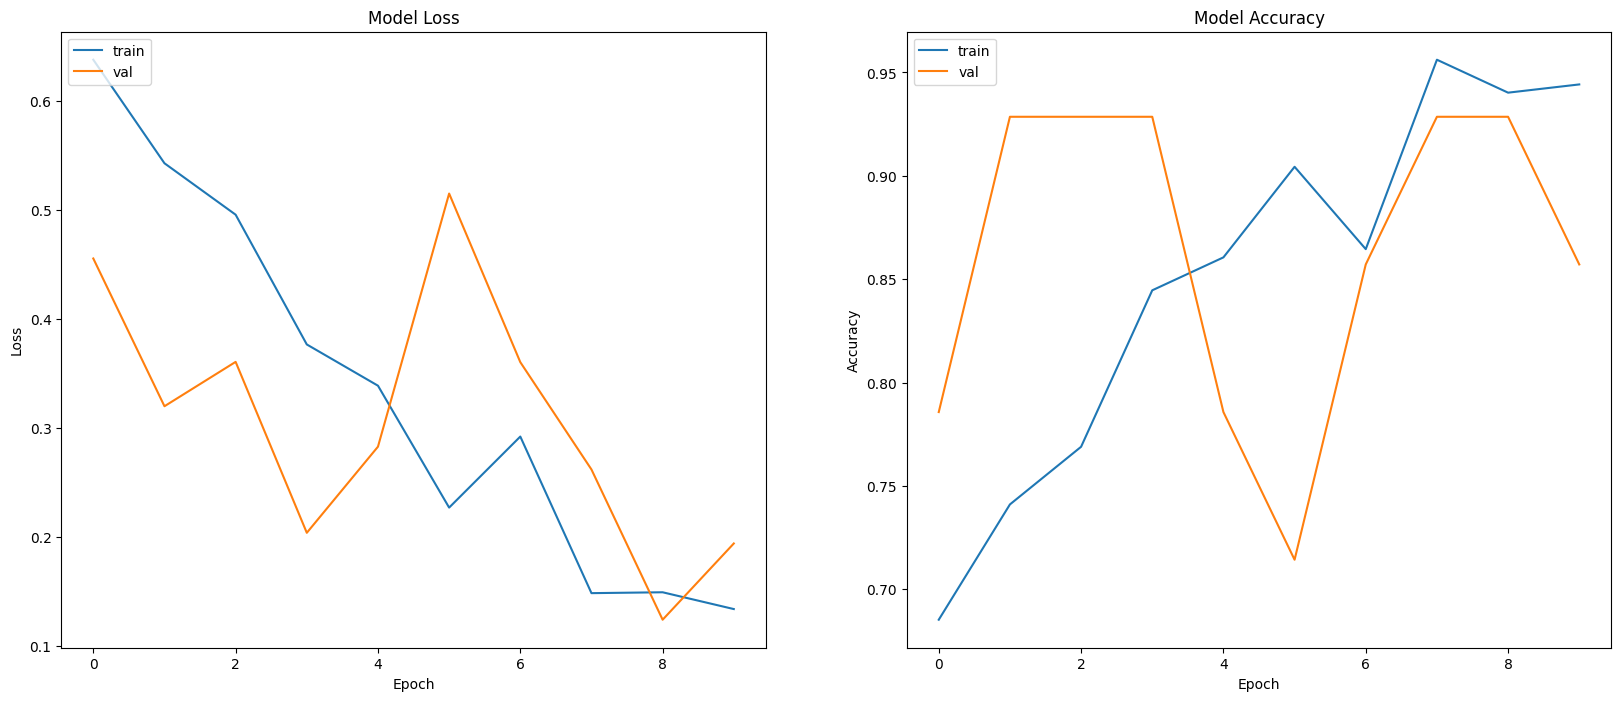

In [ ]:
# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

# Plot the loss in the first subplot
axs[0].plot(history.history['loss'], label='train')
axs[0].plot(history.history['val_loss'], label='val')
axs[0].set_title('Model Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend(loc='upper left')

# Plot the accuracy in the second subplot
axs[1].plot(history.history['accuracy'], label='train')
axs[1].plot(history.history['val_accuracy'], label='val')
axs[1].set_title('Model Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend(loc='upper left')

# Display the plots
plt.show()

### 6. Evaluasi Model

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
y_val = validation_generator.classes
y_pred = model.predict(validation_generator)
y_pred = np.argmax(y_pred,axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step


              precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.83      0.83      0.83         6

    accuracy                           0.86        14
   macro avg       0.85      0.85      0.85        14
weighted avg       0.86      0.86      0.86        14



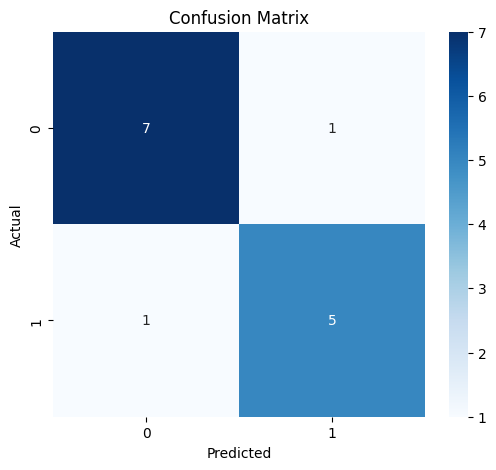

In [ ]:
from sklearn.metrics import confusion_matrix

print(classification_report(y_val,y_pred))

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
class_indices = validation_generator.class_indices

indices = {v:k for k,v in class_indices.items()}
filenames = validation_generator.filenames

val_df = pd.DataFrame()
val_df['filename'] = filenames
val_df['actual'] = y_val
val_df['predicted'] = y_pred
val_df['actual'] = val_df['actual'].apply(lambda x: indices[x])
val_df['predicted'] = val_df['predicted'].apply(lambda x: indices[x])
val_df.loc[val_df['actual']==val_df['predicted'],'Same'] = True
val_df.loc[val_df['actual']!=val_df['predicted'],'Same'] = False
val_df.head(10)

,filename,actual,predicted,Same
0,apples/img_p1_111.jpeg,apples,tomatoes,False
1,apples/img_p1_121.jpeg,apples,apples,True
2,apples/img_p1_127.jpeg,apples,apples,True
3,apples/img_p1_131.jpeg,apples,apples,True
4,apples/img_p1_133.jpeg,apples,apples,True
5,apples/img_p1_139.jpeg,apples,apples,True
6,apples/img_p1_14.jpeg,apples,apples,True
7,apples/img_p1_143.jpeg,apples,apples,True
8,tomatoes/img_p1_105.jpeg,tomatoes,apples,False
9,tomatoes/img_p1_107.jpeg,tomatoes,tomatoes,True


### Prediksi Model yang tepat dan tidak tepat

In [ ]:
val_df = val_df.sample(frac=1).reset_index(drop=True)

In [ ]:
def readImage(path):
    img = load_img(path,color_mode='rgb',target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.

    return img


def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize=(20, 20))
    n = 0
    # Loop up to the smaller of 15 or the length of temp_df
    for i in range(min(15, len(temp_df))):
        n += 1
        plt.subplot(5, 5, n)
        plt.subplots_adjust(hspace=0.5, wspace=0.3)
        image = readImage(path=f"/content/drive/MyDrive/UAS Citra/test/{temp_df.filename[i]}")
        plt.imshow(image)
        plt.title(f'A: {temp_df.actual[i]} P: {temp_df.predicted[i]}')

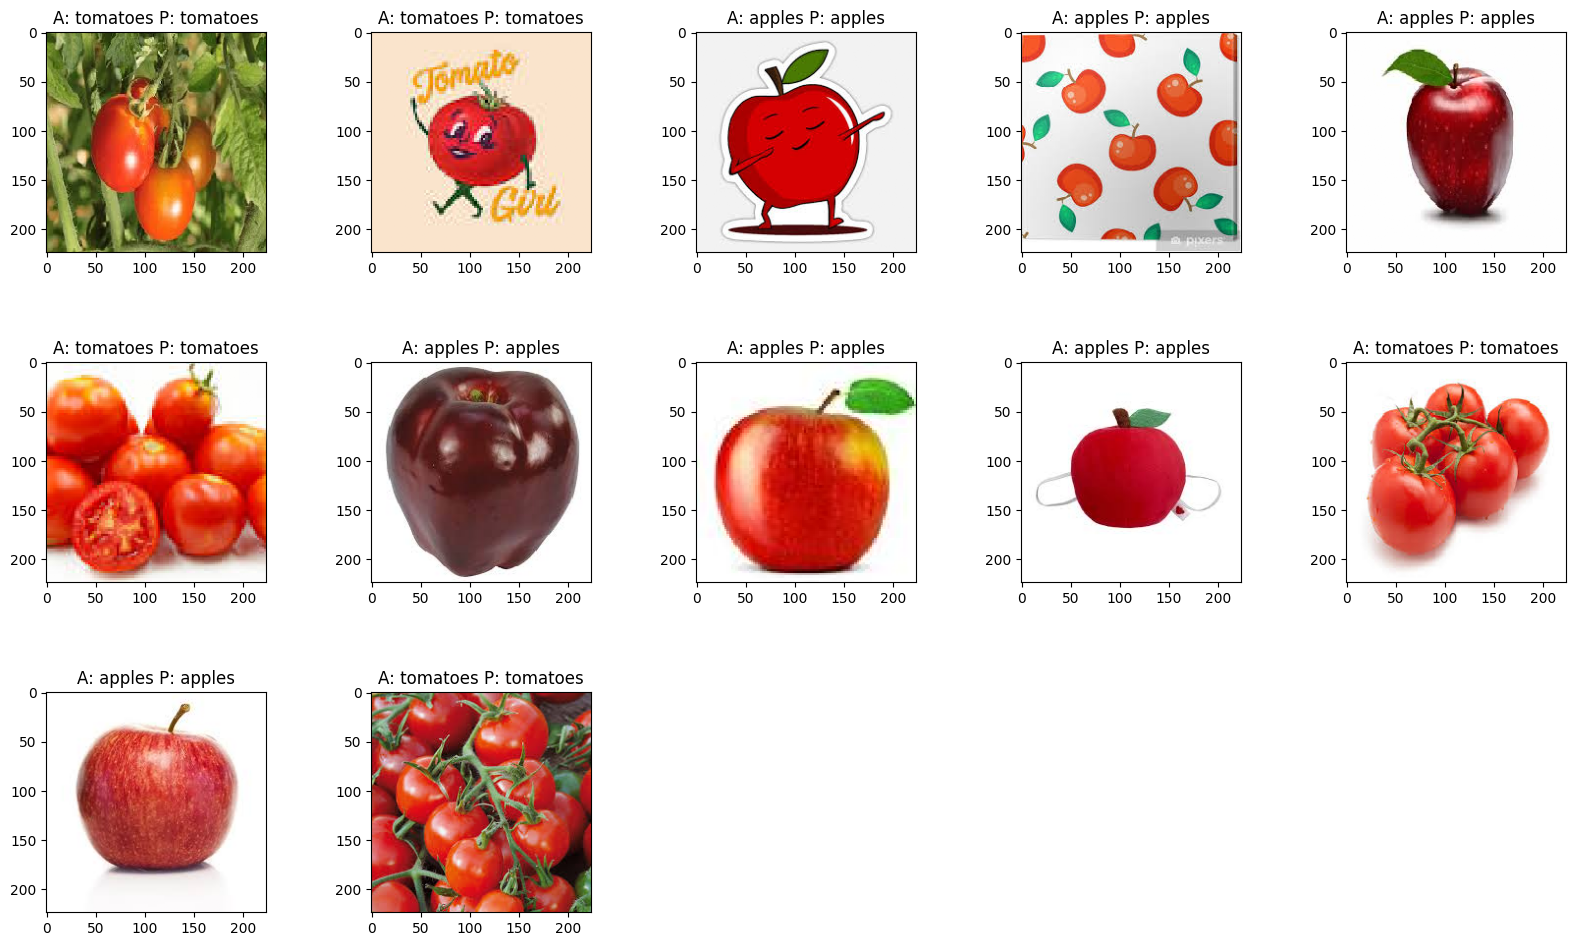

In [ ]:
display_images(val_df[val_df['Same']==True])

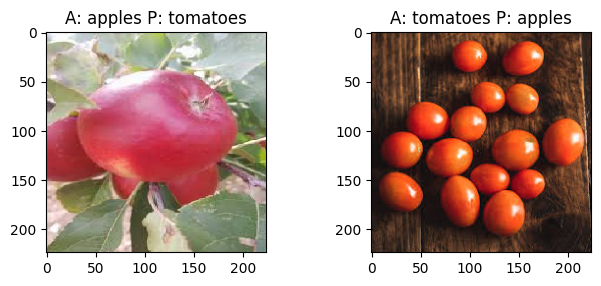

In [ ]:
display_images(val_df[val_df['Same']!=True])